# Z4 PRS production scan — analysis

Analysis of the `scan_z4_prs_prod` runs ($\mu=0.1$, $H_0=\mu$, $k_{\rm cut}=3$, $N=512$, $L=100$,
`tMax=50`).  The full planned matrix is **16 cards**:

- **std** ($\gamma=0$) and **prs** (staged PRS, `prsStartA=30`, `prsDamping=1`) across
  **$\beta_4\in\{0.1,0.3,0.5,0.7,0.9\}$** — a $\beta_4$ scan;
- **negG** ($\gamma=-0.15,-0.3,-0.6$) and **posG** ($\gamma=+0.5,+1.0,+2.0$) at $\beta_4=0.1$ —
  a friction-$\gamma$ scan ("G" $=$ `frictionGamma`).

Several cards are **still running or not yet started** (only the $\beta_4=0.1$ slice had data when
this was written).  Following `Z4_scan_altparam.ipynb`, every loader returns `None` for a
missing / empty / partially written run, so **the notebook tries to load all 16 cards and silently
skips the ones that aren't there yet** — just re-run it as more finish and they appear automatically.

Four discrete colour groups: **std** (greys, shaded by $\beta_4$), **prs** (greens dashed, by
$\beta_4$), **negG** (blues, by $|\gamma|$), **posG** (reds, by $|\gamma|$).

Plot sections, in the required order, each a single panel or at most two subplots:
1. **Wall-area parameters $\mathcal{A}_1$ / $\mathcal{A}_2$** (assumptions stated on the figure),
2. **Scalar field — average & rms**,
3. **Energies**.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import rc

# usetex matches the Z4_scan_altparam.ipynb styling; flip to False if LaTeX is unavailable.
USETEX = True
rc('text', usetex=USETEX)
rc('font', **{'family': 'sans-serif', 'sans-serif': ['Helvetica'],
              'weight': 'bold', 'size': 16})

## Configuration

`BASE` points at the production scan.  Each entry in `CONFIGS` is one planned run directory with
its group, $\beta_4$ and $\gamma$.  Colours encode the **four discrete groups**; within std/prs the
shade tracks $\beta_4$, within negG/posG it tracks $|\gamma|$ (darker = larger).

`average_energies.txt` columns (11): `eta, Ek_1, Ek_2, Eg_1, Eg_2, Ev_1, Ev_2, Ev_3, E_tot,
Scal_type_1, Scal_type_2`.  `Scal_type_1` = adjacent walls ($\theta\to\theta+\pi/2$),
`Scal_type_2` = diagonal walls ($\theta\to\theta+\pi$).

In [2]:
BASE = "/mt/user-batch/dpasari/scan_z4_prs_prod/"

# Fixed across every card
MU      = 0.1
N_LAT   = 512
LSIDE   = 100
DX      = LSIDE / N_LAT

BETA4_VALS = [0.1, 0.3, 0.5, 0.7, 0.9]

def b4_dirtag(b):
    # 0.1 -> 'b40p1', 0.3 -> 'b40p3', ...
    return "b4" + f"{b:g}".replace(".", "p")

# ── Full planned 16-card matrix.  name, directory, group, beta4, gamma, prsStartA ──
CONFIGS = []
for b in BETA4_VALS:                                   # std + prs : beta4 scan (gamma = 0)
    CONFIGS.append(dict(name=f"std_b{b:g}", dir=f"results_DWZ4_{b4_dirtag(b)}_std",
                        group="std", beta4=b, gamma=0.0, prsStartA=None))
    CONFIGS.append(dict(name=f"prs_b{b:g}", dir=f"results_DWZ4_{b4_dirtag(b)}_prs",
                        group="prs", beta4=b, gamma=0.0, prsStartA=30))
for tag, g in [("negG0p15", -0.15), ("negG0p3", -0.30), ("negG0p6", -0.60),
               ("posG0p5", 0.50),  ("posG1p0", 1.00),  ("posG2p0", 2.00)]:
    grp = "negG" if g < 0 else "posG"
    nice = tag[:4] + tag[4:].replace("p", ".")   # keep 'negG'/'posG', fix the numeric 'p'
    CONFIGS.append(dict(name=nice, dir=f"results_DWZ4_b40p1_{tag}",
                        group=grp, beta4=0.1, gamma=g, prsStartA=None))

# ── Colour = group (4 discrete families); shade = beta4 (std/prs) or |gamma| (negG/posG) ──
def _assign_styles(configs):
    def shade(cmap, vals):
        order = sorted(set(vals))
        cols = cmap(np.linspace(0.45, 0.90, max(len(order), 1)))
        return {v: cols[i] for i, v in enumerate(order)}
    grp = {g: [c for c in configs if c["group"] == g] for g in ("std", "prs", "negG", "posG")}
    std_sh = shade(plt.cm.Greys,  [c["beta4"] for c in grp["std"]])
    prs_sh = shade(plt.cm.Greens, [c["beta4"] for c in grp["prs"]])
    neg_sh = shade(plt.cm.Blues,  [abs(c["gamma"]) for c in grp["negG"]])
    pos_sh = shade(plt.cm.Reds,   [abs(c["gamma"]) for c in grp["posG"]])
    for c in grp["std"]:
        c["color"], c["ls"], c["lw"] = std_sh[c["beta4"]], "solid", 2.4
    for c in grp["prs"]:
        c["color"], c["ls"], c["lw"] = prs_sh[c["beta4"]], (0, (5, 2)), 2.4
    for c in grp["negG"]:
        c["color"], c["ls"], c["lw"] = neg_sh[abs(c["gamma"])], "solid", 2.1
    for c in grp["posG"]:
        c["color"], c["ls"], c["lw"] = pos_sh[abs(c["gamma"])], "solid", 2.1

_assign_styles(CONFIGS)

GROUP_REP = {"std": "black", "prs": "#2ca02c", "negG": "#08519c", "posG": "#cb181d"}

def cfg_label(c):
    if c["group"] == "std":
        return r"std $\beta_4=%g$" % c["beta4"]
    if c["group"] == "prs":
        return r"prs $\beta_4=%g$" % c["beta4"]
    return r"$\gamma=%+.2g$ ($\beta_4=0.1$)" % c["gamma"]

print(f"{len(CONFIGS)} planned cards:")
for c in CONFIGS:
    print(f"  {c['name']:10s} group={c['group']:5s} beta4={c['beta4']:.1f} gamma={c['gamma']:+.2f}")

16 planned cards:
  std_b0.1   group=std   beta4=0.1 gamma=+0.00
  prs_b0.1   group=prs   beta4=0.1 gamma=+0.00
  std_b0.3   group=std   beta4=0.3 gamma=+0.00
  prs_b0.3   group=prs   beta4=0.3 gamma=+0.00
  std_b0.5   group=std   beta4=0.5 gamma=+0.00
  prs_b0.5   group=prs   beta4=0.5 gamma=+0.00
  std_b0.7   group=std   beta4=0.7 gamma=+0.00
  prs_b0.7   group=prs   beta4=0.7 gamma=+0.00
  std_b0.9   group=std   beta4=0.9 gamma=+0.00
  prs_b0.9   group=prs   beta4=0.9 gamma=+0.00
  negG0.15   group=negG  beta4=0.1 gamma=-0.15
  negG0.3    group=negG  beta4=0.1 gamma=-0.30
  negG0.6    group=negG  beta4=0.1 gamma=-0.60
  posG0.5    group=posG  beta4=0.1 gamma=+0.50
  posG1.0    group=posG  beta4=0.1 gamma=+1.00
  posG2.0    group=posG  beta4=0.1 gamma=+2.00


## Loader functions

Each loader returns `None` for a missing, empty, or partially written file — that is how the
notebook *checks whether a card has produced output before trying to plot it*.

In [3]:
def _safe_loadtxt(fpath):
    """np.loadtxt that tolerates missing / empty / mid-write (ragged) files."""
    try:
        if not os.path.exists(fpath) or os.path.getsize(fpath) == 0:
            return None
        data = np.loadtxt(fpath)
    except (FileNotFoundError, OSError, ValueError, StopIteration):
        return None
    if data.size == 0:
        return None
    if data.ndim == 1:
        data = data[np.newaxis, :]
    return data


def load_energies(path):
    """average_energies.txt -> dict, or None.  11 cols incl. the 2 Z4 wall columns."""
    data = _safe_loadtxt(os.path.join(path, "average_energies.txt"))
    if data is None or data.shape[1] < 11:
        return None
    return {
        "eta":   data[:, 0], "Ek_1": data[:, 1], "Ek_2": data[:, 2],
        "Eg_1":  data[:, 3], "Eg_2": data[:, 4], "Ev_1": data[:, 5],
        "Ev_2":  data[:, 6], "Ev_3": data[:, 7], "E_tot": data[:, 8],
        "scal1": data[:, 9],     # Scal_type_1  (adjacent,  theta -> theta+pi/2)
        "scal2": data[:, 10],    # Scal_type_2  (diagonal,  theta -> theta+pi)
    }


def load_scalar(path, idx):
    """average_scalar_{idx}.txt -> dict, or None.  idx 0 = h, 1 = a."""
    data = _safe_loadtxt(os.path.join(path, f"average_scalar_{idx}.txt"))
    if data is None or data.shape[1] < 6:
        return None
    return {
        "eta": data[:, 0], "phi": data[:, 1], "phi_prime": data[:, 2],
        "phi2": data[:, 3], "phi_prime2": data[:, 4],
        "rms_phi": data[:, 5], "rms_phi_p": data[:, 6] if data.shape[1] > 6 else data[:, 5],
    }


def load_scale_factor(path):
    """average_scale_factor.txt -> dict, or None."""
    data = _safe_loadtxt(os.path.join(path, "average_scale_factor.txt"))
    if data is None or data.shape[1] < 4:
        return None
    return {"eta": data[:, 0], "a": data[:, 1], "aprime": data[:, 2], "H": data[:, 3]}

## Load all runs — *plot only what has run*

Tries every card; `MISSING` rows are runs not yet finished (or not yet started) and are simply
skipped.  Re-run this notebook later and they will be picked up automatically.

In [4]:
datasets = []
for c in CONFIGS:
    path = os.path.join(BASE, c["dir"])
    en = load_energies(path)
    sf = load_scale_factor(path)
    s0 = load_scalar(path, 0)
    s1 = load_scalar(path, 1)

    ok = en is not None and sf is not None
    last_eta = f"{en['eta'][-1]:6.1f}" if ok else "  --  "
    print(f"{'OK ' if ok else 'MISSING':8s} {c['name']:10s}  last_eta={last_eta}  {c['dir']}")

    d = dict(c)
    d.update(label=cfg_label(c), energies=en, scale_factor=sf, scalar_0=s0, scalar_1=s1)
    datasets.append(d)

ready = [d for d in datasets if d["energies"] is not None and d["scale_factor"] is not None]
print(f"\nReady: {len(ready)} / {len(datasets)}")

OK       std_b0.1    last_eta=  49.9  results_DWZ4_b40p1_std
OK       prs_b0.1    last_eta=  49.9  results_DWZ4_b40p1_prs
OK       std_b0.3    last_eta=  49.9  results_DWZ4_b40p3_std
OK       prs_b0.3    last_eta=  49.9  results_DWZ4_b40p3_prs
OK       std_b0.5    last_eta=  49.9  results_DWZ4_b40p5_std
OK       prs_b0.5    last_eta=  49.9  results_DWZ4_b40p5_prs
OK       std_b0.7    last_eta=  49.9  results_DWZ4_b40p7_std
OK       prs_b0.7    last_eta=  49.9  results_DWZ4_b40p7_prs
OK       std_b0.9    last_eta=  49.9  results_DWZ4_b40p9_std
OK       prs_b0.9    last_eta=  49.9  results_DWZ4_b40p9_prs
OK       negG0.15    last_eta=  49.9  results_DWZ4_b40p1_negG0p15
OK       negG0.3     last_eta=  49.9  results_DWZ4_b40p1_negG0p3
OK       negG0.6     last_eta=  49.9  results_DWZ4_b40p1_negG0p6
OK       posG0.5     last_eta=  49.9  results_DWZ4_b40p1_posG0p5
OK       posG1.0     last_eta=  49.9  results_DWZ4_b40p1_posG1p0
OK       posG2.0     last_eta=  49.9  results_DWZ4_b40p1_posG2p0

## Plot helpers

In [5]:
def paper_ax(ax, xlabel=r"$\eta$", ylabel="", title=""):
    ax.set_xlabel(xlabel, fontsize=24)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=24)
    if title:
        ax.set_title(title, fontsize=20)
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    ax.tick_params(axis='both', which='both', direction='in', labelsize=18, pad=6)
    ax.tick_params(which='major', length=9)
    ax.tick_params(which='minor', length=4)
    ax.minorticks_on()
    ax.grid(True, linestyle='--', linewidth=0.4, alpha=0.6)


def area_param(en_key, d):
    """Wall-area parameter A_k = scal_k / (2 a H), eta-aligned."""
    en, sf = d["energies"], d["scale_factor"]
    n = min(len(en["eta"]), len(sf["a"]))
    scal, a, H = en[en_key][:n], sf["a"][:n], sf["H"][:n]
    with np.errstate(divide='ignore', invalid='ignore'):
        A = scal / (2.0 * a * H)
    return en["eta"][:n], A


def breaking_onset(d):
    """eta at which Ev_1 first goes negative (symmetry breaking), or None."""
    en = d["energies"]
    neg = np.where(en["Ev_1"] < 0)[0]
    return en["eta"][neg[0]] if neg.size else None


def config_handles(items):
    return [Line2D([0], [0], color=d["color"], lw=max(d["lw"], 2.4), linestyle=d["ls"],
                   label=d["label"]) for d in items]

# V_0 = |Ev_1| at phi=0 (value of the mass term at the symmetric maximum)
V0 = float(ready[0]["energies"]["Ev_1"][0]) if ready else 0.0
print(f"Ready runs: {len(ready)};  V0 (Ev_1 at phi=0) = {V0:.3e}")

Ready runs: 16;  V0 (Ev_1 at phi=0) = 2.489e-03


## 1. Wall-area parameters $\mathcal{A}_1$ and $\mathcal{A}_2$

$\mathcal{A}_k = \mathrm{Scal\_type\_}k / (2aH)$.  **Left** = type-1 (adjacent), **right** = type-2
(diagonal).  Markers ($\bullet$) flag each run's symmetry-breaking onset (first $E_{v,1}<0$):
$\mathcal{A}$ is only physical wall area to the **right** of the marker — see the assumptions box.

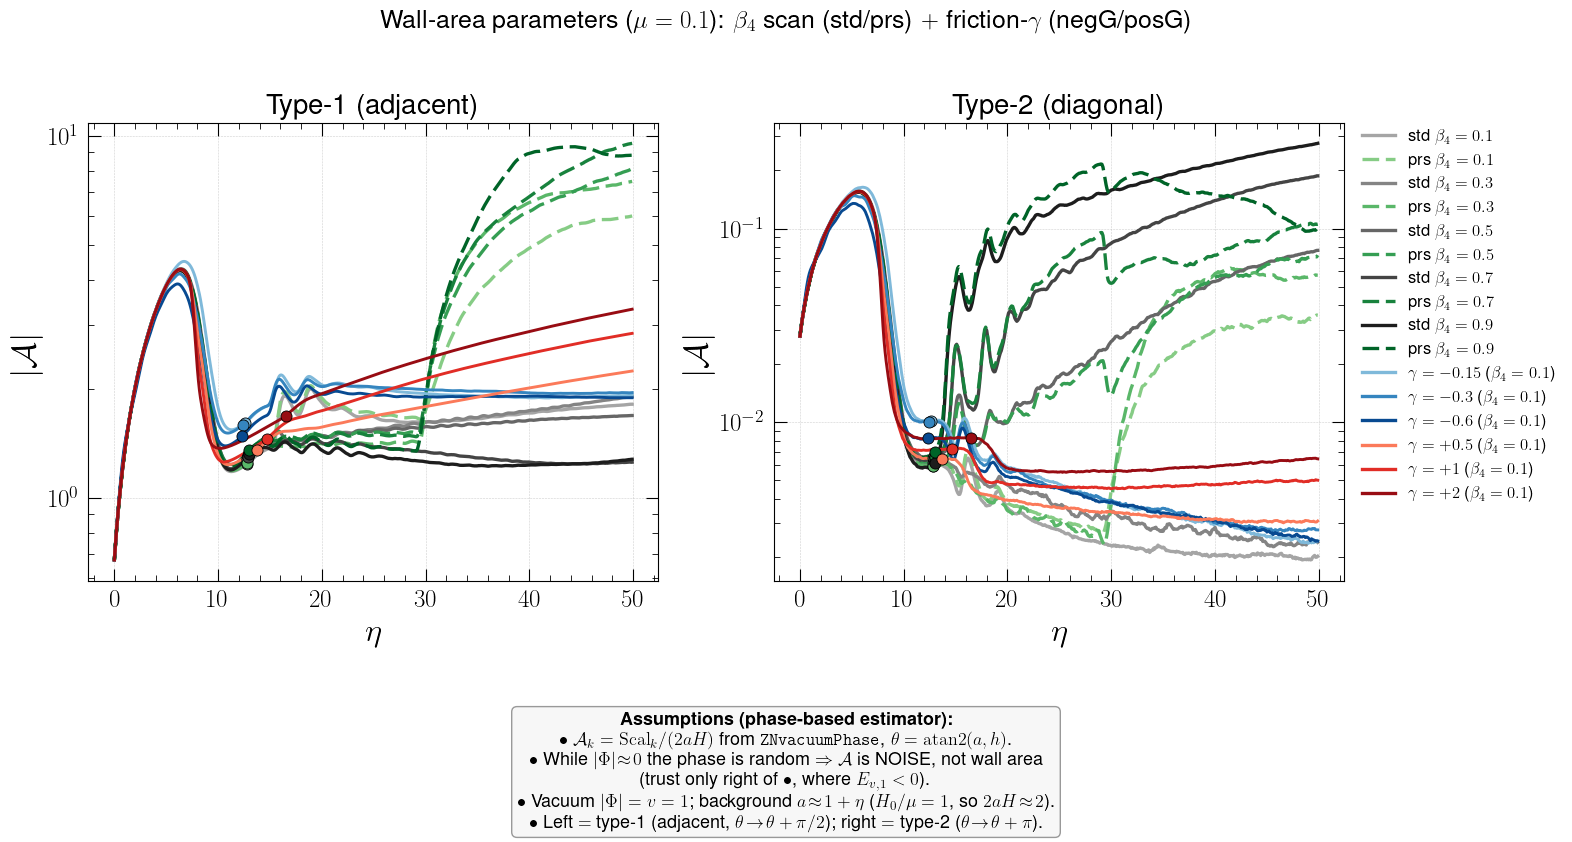

In [ ]:


fig, axes = plt.subplots(1, 2, figsize=(16, 6.5), sharex=True)
for d in ready:
    eta1, A1 = area_param("scal1", d)
    eta2, A2 = area_param("scal2", d)
    axes[0].plot(eta1, np.abs(A1), color=d["color"], ls=d["ls"], lw=d["lw"])
    axes[1].plot(eta2, np.abs(A2), color=d["color"], ls=d["ls"], lw=d["lw"])
    eta_b = breaking_onset(d)
    if eta_b is not None:
        for ax, (eta, A) in zip(axes, [(eta1, A1), (eta2, A2)]):
            k = int(np.argmin(np.abs(eta - eta_b)))
            ax.plot(eta[k], abs(A[k]), 'o', color=d["color"], ms=8,
                    mec='k', mew=0.6, zorder=5)

for ax, ttl in zip(axes, [r"Type-1 (adjacent)", r"Type-2 (diagonal)"]):
    paper_ax(ax, ylabel=r"$|\mathcal{A}|$", title=ttl)
    ax.set_yscale('log')

axes[1].legend(handles=config_handles(ready), fontsize=12, frameon=False,
               loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0)

fig.suptitle(r"Wall-area parameters  ($\mu=0.1$): $\beta_4$ scan (std/prs) $+$ friction-$\gamma$ (negG/posG)",
             fontsize=18, y=1.02)
plt.tight_layout()
plt.savefig("Z4prsprod_area.pdf", bbox_inches="tight")
plt.show()

## 2. Scalar field — average and rms

Components: $\phi_0=h$ (Higgs-like), $\phi_1=a$ (axion-like).  At a Z4 vacuum
$|\Phi|=v=1$ each component sits near $\pm v/\sqrt2\approx0.707$.  First the mean $\pm\sigma$,
then $\sqrt{\langle\phi^2\rangle}$ (the symmetry-breaking order parameter).

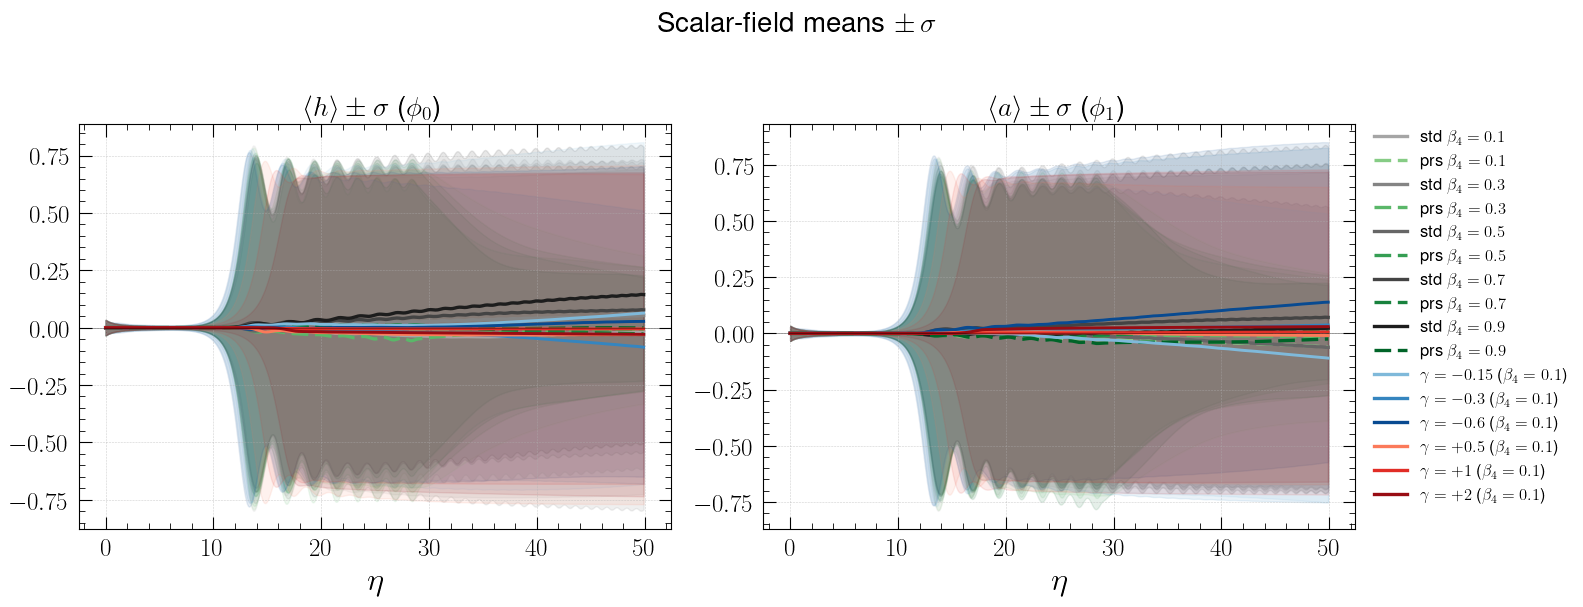

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
for d in ready:
    for ax, fkey in zip(axes, ("scalar_0", "scalar_1")):
        sc = d.get(fkey)
        if sc is None:
            continue
        sigma = np.sqrt(np.maximum(sc["phi2"] - sc["phi"]**2, 0.0))
        ax.fill_between(sc["eta"], sc["phi"] - sigma, sc["phi"] + sigma,
                        alpha=0.10, color=d["color"])
        ax.plot(sc["eta"], sc["phi"], color=d["color"], ls=d["ls"], lw=d["lw"])

for ax, ttl in zip(axes, [r"$\langle h\rangle\pm\sigma$  ($\phi_0$)",
                          r"$\langle a\rangle\pm\sigma$  ($\phi_1$)"]):
    paper_ax(ax, ylabel="", title=ttl)
    ax.axhline(0, color='k', lw=0.6, alpha=0.4)
axes[1].legend(handles=config_handles(ready), fontsize=12, frameon=False,
               loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
fig.suptitle(r"Scalar-field means  $\pm\,\sigma$", fontsize=20, y=1.02)
plt.tight_layout()
plt.savefig("Z4prsprod_field_mean.pdf", bbox_inches="tight")
plt.show()

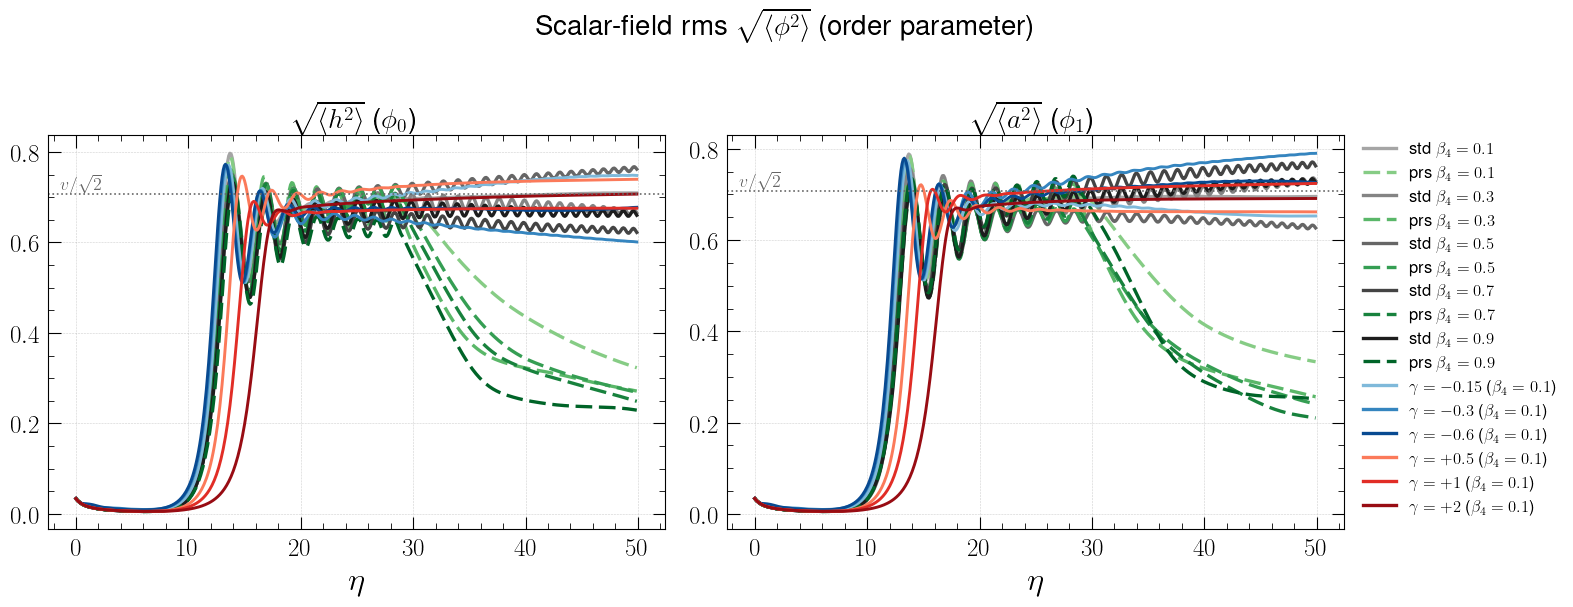

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
for d in ready:
    for ax, fkey in zip(axes, ("scalar_0", "scalar_1")):
        sc = d.get(fkey)
        if sc is None:
            continue
        ax.plot(sc["eta"], np.sqrt(np.maximum(sc["phi2"], 0.0)),
                color=d["color"], ls=d["ls"], lw=d["lw"])

for ax, ttl in zip(axes, [r"$\sqrt{\langle h^2\rangle}$  ($\phi_0$)",
                          r"$\sqrt{\langle a^2\rangle}$  ($\phi_1$)"]):
    paper_ax(ax, ylabel="", title=ttl)
    ax.axhline(1/np.sqrt(2), color='0.4', ls=':', lw=1.2)
    ax.text(0.02, 1/np.sqrt(2), r"$v/\sqrt2$", color='0.4', fontsize=13,
            va='bottom', ha='left', transform=ax.get_yaxis_transform())
axes[1].legend(handles=config_handles(ready), fontsize=12, frameon=False,
               loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
fig.suptitle(r"Scalar-field rms  $\sqrt{\langle\phi^2\rangle}$  (order parameter)",
             fontsize=20, y=1.02)
plt.tight_layout()
plt.savefig("Z4prsprod_field_rms.pdf", bbox_inches="tight")
plt.show()

## 3. Energies

**Left:** gradient energy $E_{\rm grad}=E_{g,1}+E_{g,2}$ (log) — a proxy for structure / wall
surface.  **Right:** mass-potential term $E_{v,1}$ with $\pm V_0$ guides; $E_{v,1}$ crossing from
$+V_0$ (symmetric maximum) to $-V_0$ marks symmetry breaking.  Then a single-panel total energy.

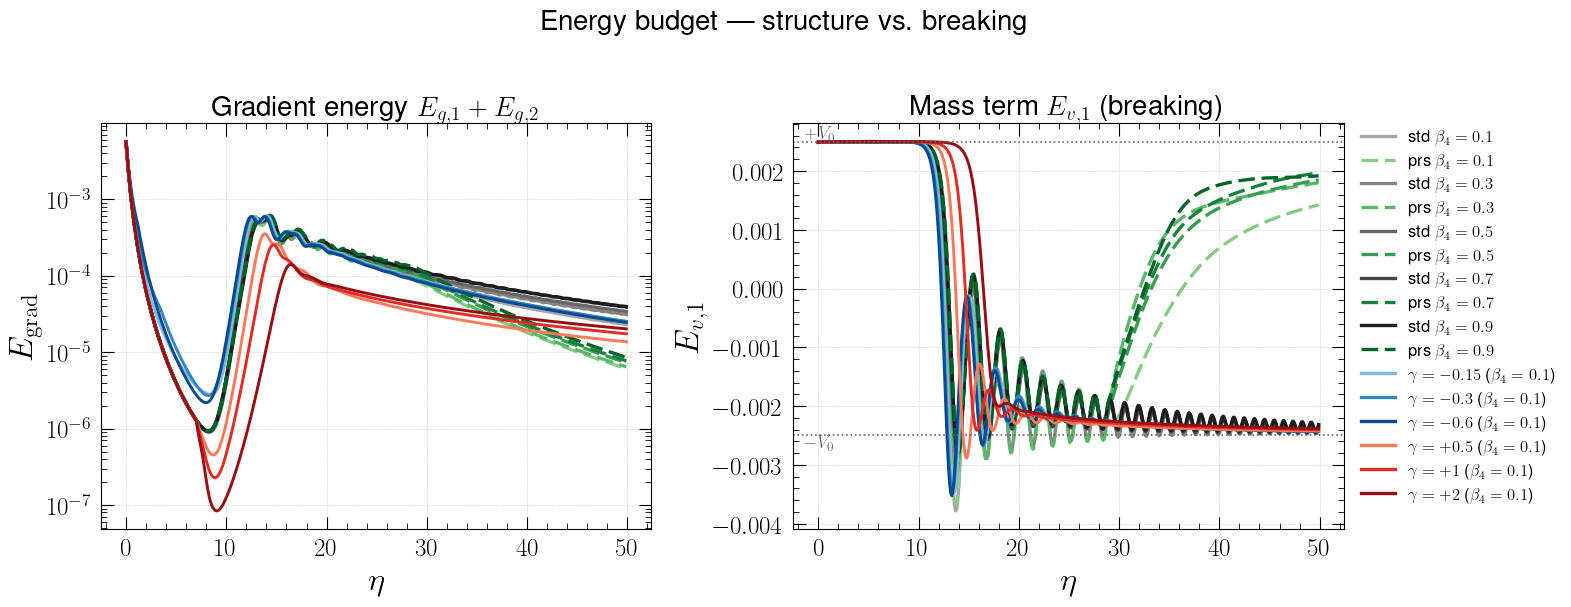

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
for d in ready:
    en = d["energies"]
    axes[0].plot(en["eta"], en["Eg_1"] + en["Eg_2"],
                 color=d["color"], ls=d["ls"], lw=d["lw"])
    axes[1].plot(en["eta"], en["Ev_1"],
                 color=d["color"], ls=d["ls"], lw=d["lw"])

paper_ax(axes[0], ylabel=r"$E_{\rm grad}$", title=r"Gradient energy $E_{g,1}+E_{g,2}$")
axes[0].set_yscale('log')
paper_ax(axes[1], ylabel=r"$E_{v,1}$", title=r"Mass term $E_{v,1}$ (breaking)")
for s in (+1, -1):
    axes[1].axhline(s * V0, color='0.4', ls=':', lw=1.2)
axes[1].text(0.02, +V0, r"$+V_0$", color='0.4', fontsize=13, va='bottom',
             transform=axes[1].get_yaxis_transform())
axes[1].text(0.02, -V0, r"$-V_0$", color='0.4', fontsize=13, va='top',
             transform=axes[1].get_yaxis_transform())
axes[1].legend(handles=config_handles(ready), fontsize=12, frameon=False,
               loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
fig.suptitle(r"Energy budget — structure vs. breaking", fontsize=20, y=1.02)
plt.tight_layout()
plt.savefig("Z4prsprod_energy.pdf", bbox_inches="tight")
plt.show()

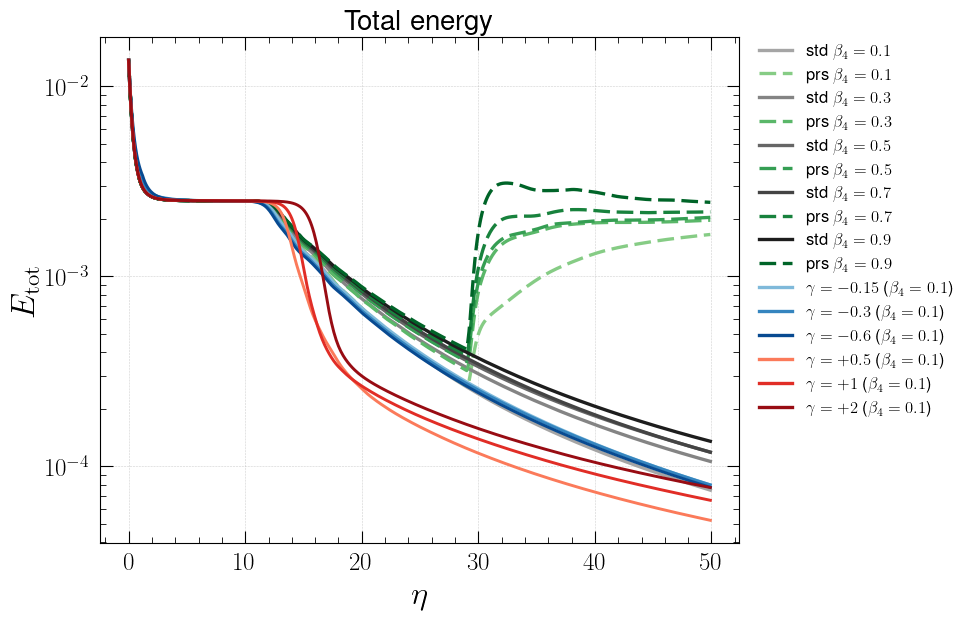

In [10]:
fig, ax = plt.subplots(figsize=(10, 6.5))
for d in ready:
    en = d["energies"]
    ax.plot(en["eta"], en["E_tot"], color=d["color"], ls=d["ls"], lw=d["lw"])
paper_ax(ax, ylabel=r"$E_{\rm tot}$", title=r"Total energy")
ax.set_yscale('log')
ax.legend(handles=config_handles(ready), fontsize=12, frameon=False,
          loc='upper left', bbox_to_anchor=(1.02, 1.0), borderaxespad=0)
plt.tight_layout()
plt.savefig("Z4prsprod_etot.pdf", bbox_inches="tight")
plt.show()

## Summary — breaking onset

Per ready run: symmetry-breaking onset ($E_{v,1}<0$), peak $\sqrt{\langle h^2\rangle}$, and the
final $\eta$ reached (runs still in progress simply stop short).  At fixed $\beta_4=0.1,\mu=0.1$
the friction sign shifts the onset: negative $\gamma$ (anti-damping) breaks earlier, positive
$\gamma$ later.

In [11]:
print(f"{'card':11s} {'beta4':>6s} {'gamma':>7s} {'break @eta':>11s} "
      f"{'peak rms h':>11s} {'final eta':>10s}")
print("-" * 62)
for d in ready:
    eta_b = breaking_onset(d)
    s0 = d.get("scalar_0")
    peak = np.sqrt(np.maximum(s0["phi2"], 0.0)).max() if s0 is not None else float('nan')
    print(f"{d['name']:11s} {d['beta4']:>6.1f} {d['gamma']:+7.2f} "
          f"{(f'{eta_b:.1f}' if eta_b is not None else 'none'):>11s} "
          f"{peak:>11.3f} {d['energies']['eta'][-1]:>10.1f}")

card         beta4   gamma  break @eta  peak rms h  final eta
--------------------------------------------------------------
std_b0.1       0.1   +0.00        12.8       0.797       49.9
prs_b0.1       0.1   +0.00        12.8       0.789       49.9
std_b0.3       0.3   +0.00        12.8       0.739       49.9
prs_b0.3       0.3   +0.00        12.8       0.760       49.9
std_b0.5       0.5   +0.00        12.9       0.767       49.9
prs_b0.5       0.5   +0.00        12.9       0.748       49.9
std_b0.7       0.7   +0.00        12.9       0.720       49.9
prs_b0.7       0.7   +0.00        13.0       0.744       49.9
std_b0.9       0.9   +0.00        13.0       0.733       49.9
prs_b0.9       0.9   +0.00        13.0       0.717       49.9
negG0.15       0.1   -0.15        12.6       0.771       49.9
negG0.3        0.1   -0.30        12.4       0.770       49.9
negG0.6        0.1   -0.60        12.3       0.773       49.9
posG0.5        0.1   +0.50        13.7       0.746       49.9
posG1.0